In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("imdb_reviews.csv")

In [ ]:
# separar features y target
X = df["review"]
y = df["label"]

# split train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# split dev y test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(len(X_train), len(X_dev), len(X_test))

35000 7500 7500


In [10]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),   # unigramas + bigramas
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ))
])

In [11]:
pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [12]:
y_pred_dev = pipeline.predict(X_dev)

acc = accuracy_score(y_dev, y_pred_dev)

print(f"Accuracy (DEV): {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_dev, y_pred_dev))

Accuracy (DEV): 0.8908

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      3750
           1       0.88      0.90      0.89      3750

    accuracy                           0.89      7500
   macro avg       0.89      0.89      0.89      7500
weighted avg       0.89      0.89      0.89      7500



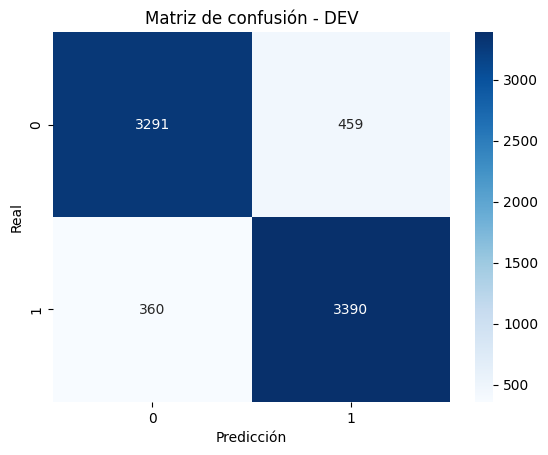

In [13]:
cm = confusion_matrix(y_dev, y_pred_dev)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - DEV")
plt.show()

In [14]:
feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()
coefs = pipeline.named_steps["clf"].coef_[0]

top_pos_idx = coefs.argsort()[-20:]
top_neg_idx = coefs.argsort()[:20]

print("Top positivas:")
print([feature_names[i] for i in top_pos_idx])

print("\nTop negativas:")
print([feature_names[i] for i in top_neg_idx])

Top positivas:
['love', 'enjoyable', 'definitely', 'gem', 'highly', 'fantastic', 'enjoyed', 'hilarious', 'superb', 'fun', 'loved', 'today', 'brilliant', 'favorite', 'perfect', 'wonderful', 'amazing', 'best', 'excellent', 'great']

Top negativas:
['worst', 'bad', 'awful', 'boring', 'waste', 'terrible', 'poor', 'worse', 'horrible', 'dull', 'poorly', 'disappointment', 'instead', 'fails', 'unfortunately', 'minutes', 'ridiculous', 'lame', 'disappointing', 'avoid']
